## Unsupervised Machine Learning




## Tasks
1. Create a random dataset using sklearn.datasets.make_classification  (200-1000 rows, 2 features, 3-10 classes)
2. fit a kmeans model
3. display the model result (e.g. Meshgrid-Plot like in the lecture)
4. Calculate the silhouette_score
5. Investigate how the following influence *(using n_init=1 for better comparison)* the silhouette score and discuss the outcome:
    
    5.1.: Three different k-values between 1 and 10
        
    5.2.: three different random seeds prior fitting the model

## Imports & Setup

In [36]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Reproducibility seed for dataset generation
RANDOM_STATE = 42

## Task 1 – Generate Random Dataset

Using `make_classification` with:
- **500 samples** (within the required 200–1000 range)
- **2 informative features** (required for 2D visualisation)
- **4 classes** (within the required 3–10 range)

**Note:** With only 2 informative features, the maximum number of separable classes is 2^2 = 4. That's why I use 4 classes instead of 5.

Setting `n_redundant=0` and `n_repeated=0` to keep exactly 2 features. A small amount of noise (`flip_y=0.05`) is added to make the clustering problem more realistic. Features are then standardised so that KMeans (which is distance-based) is not distorted by scale.

Dataset shape : (442, 2)
Feature range : [-3.00, 2.42]
Number of classes: 4
Class distribution: {np.int64(0): np.int64(111), np.int64(1): np.int64(110), np.int64(2): np.int64(107), np.int64(3): np.int64(114)}


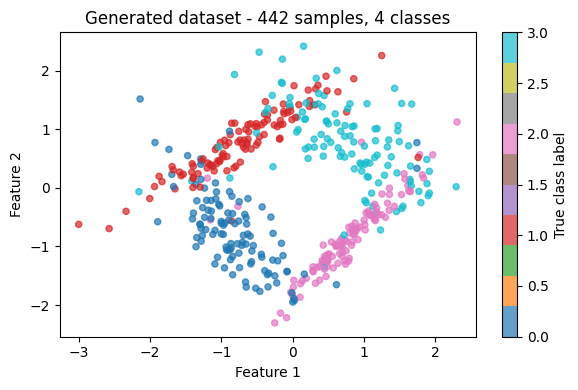

In [37]:
start, stop, step =200, 1000, 1;
N_SAMPLES  = random.randrange(start, stop, step) #500
N_FEATURES = 2
N_CLASSES  = 4  # Maximum with 2 features is 4 (2^2 = 4)

X_raw, y_true = make_classification(
    n_samples       = N_SAMPLES,
    n_features      = N_FEATURES,
    n_informative   = N_FEATURES,
    n_redundant     = 0,
    n_repeated      = 0,
    n_classes       = N_CLASSES,
    n_clusters_per_class = 1,
    flip_y          = 0.05,  # Add slight noise for realistic clustering
    random_state    = RANDOM_STATE,
)

# Standardise so KMeans is not scale-biased
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Dataset shape : {X.shape}")
print(f"Feature range : [{X.min():.2f}, {X.max():.2f}]")
print(f"Number of classes: {N_CLASSES}")
print(f"Class distribution: {dict(zip(*np.unique(y_true, return_counts=True)))}")

plt.figure(figsize=(6, 4))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap="tab10", s=20, alpha=0.7)
plt.colorbar(scatter, label="True class label")
plt.title(f"Generated dataset - {N_SAMPLES} samples, {N_CLASSES} classes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

## Task 2 – Fit a KMeans Model

Fitting KMeans with **k = 4** (matching the number of classes) as the baseline model.
- `n_init=10` (default) gives multiple restarts to avoid poor local optima.
- `random_state=42` ensures reproducibility.

In [38]:
K_BASELINE = N_CLASSES  # Using 4 5

kmeans = KMeans(n_clusters=K_BASELINE, n_init=10, random_state=RANDOM_STATE)
kmeans.fit(X)

labels     = kmeans.labels_
centroids  = kmeans.cluster_centers_
inertia    = kmeans.inertia_

print(f"KMeans fitted  |  k={K_BASELINE}  |  inertia={inertia:.2f}")
print(f"Cluster sizes  : {dict(zip(*np.unique(labels, return_counts=True)))}")

KMeans fitted  |  k=4  |  inertia=189.11
Cluster sizes  : {np.int32(0): np.int64(116), np.int32(1): np.int64(109), np.int32(2): np.int64(122), np.int32(3): np.int64(95)}


## Task 3 – Meshgrid / Decision-Boundary Plot

A dense meshgrid covering the feature space is created, every point is classified by the trained KMeans model, and the resulting decision regions are shaded.  
Data points are overlaid and centroids are marked with a star.

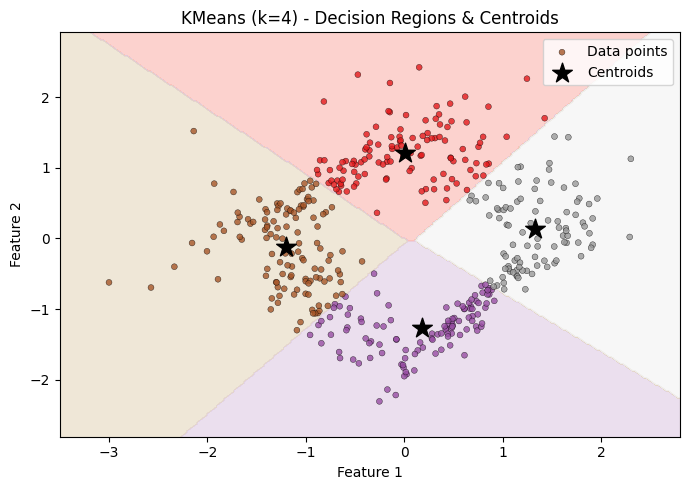

In [39]:
def plot_kmeans_meshgrid(model, X, title="KMeans – decision regions"):
    """Render a KMeans meshgrid plot with cluster boundaries."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    h = 0.02  # step size
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_bg   = plt.get_cmap("Pastel1",  model.n_clusters)
    cmap_pts  = plt.get_cmap("Set1",     model.n_clusters)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=model.labels_, cmap=cmap_pts,
               s=18, edgecolors="k", linewidths=0.3, alpha=0.8, label="Data points")
    ax.scatter(model.cluster_centers_[:, 0],
               model.cluster_centers_[:, 1],
               c="black", marker="*", s=220, zorder=5, label="Centroids")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

plot_kmeans_meshgrid(kmeans, X,
    title=f"KMeans (k={K_BASELINE}) - Decision Regions & Centroids")

## Task 4 – Silhouette Score

The **silhouette score** measures how well each point sits within its own cluster compared to the nearest neighbouring cluster.  
It ranges from **−1** (misclassified) to **+1** (perfectly clustered); values near **0** indicate overlapping clusters.

In [40]:
sil_baseline = silhouette_score(X, labels)
print(f"Silhouette Score (k={K_BASELINE}, random_state={RANDOM_STATE}): {sil_baseline:.4f}")

Silhouette Score (k=4, random_state=42): 0.4536


## Task 5 – Investigating Silhouette Score Sensitivity

All experiments below use `n_init=1` so that each run reflects a single centroid initialisation - this exposes the impact of both **k** and **random_state** without averaging them away.

---
### 5.1 – Three Different k-Values

Test **k ∈ {2, 4, 7}** with a fixed `random_state=42`. Note that 4 is the true number of classes, 2 is under-clustering, and 7 is over-clustering.

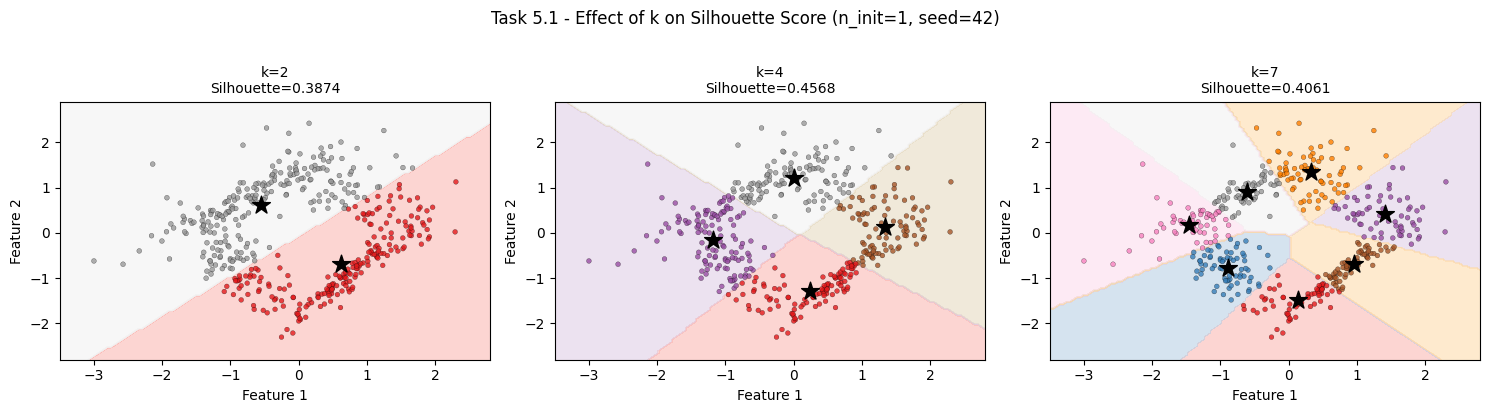


Summary (k vs silhouette score):
  k= 2  →  silhouette=0.3874
  k= 4  →  silhouette=0.4568
  k= 7  →  silhouette=0.4061


In [41]:
k_values  = [2, 4, 7]  # Using 4 as baseline (actual classes), plus smaller and larger
sil_by_k  = {}

fig, axes = plt.subplots(1, len(k_values), figsize=(15, 4), sharey=False)

for ax, k in zip(axes, k_values):
    km = KMeans(n_clusters=k, n_init=1, random_state=42)
    km.fit(X)
    sil = silhouette_score(X, km.labels_)
    sil_by_k[k] = sil

    # Meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    Z = km.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_bg  = plt.get_cmap("Pastel1", k)
    cmap_pts = plt.get_cmap("Set1",    k)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.55)
    ax.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap=cmap_pts,
               s=12, edgecolors="k", linewidths=0.2, alpha=0.8)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c="black", marker="*", s=180, zorder=5)
    ax.set_title(f"k={k}\nSilhouette={sil:.4f}", fontsize=10)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.suptitle("Task 5.1 - Effect of k on Silhouette Score (n_init=1, seed=42)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("\nSummary (k vs silhouette score):")
for k, s in sil_by_k.items():
    print(f"  k={k:2d}  →  silhouette={s:.4f}")

### Discussion - Task 5.1 (Effect of k)

| k | Expected behaviour |
|---|---|
| **k=2** | Very few clusters - distinct groups are merged together. The silhouette score is typically **low** because points from different true groups share a cluster, increasing intra-cluster distances. |
| **k=4** | Matches the actual number of classes in the generated data (maximum possible with 2 features). The algorithm has the right number of clusters to align with the underlying structure, so the silhouette score tends to be **highest** among the three values. |
| **k=7** | More clusters than true classes - some true classes are split into sub-clusters. This increases cohesion artificially but at the cost of incorrect boundaries; the silhouette score typically decreases compared to the optimal k. |

**Key takeaway:** When k is too small, distinct groups are merged (low cohesion within clusters). When k is too large, true groups are fragmented (boundaries become arbitrary). The silhouette score is a useful heuristic for choosing k - the peak often corresponds to the "natural" cluster count.

---
### 5.2 - Three Different Random Seeds

Fixing **k = 4** and test `random_state ∈ {0, 42, 99}` with `n_init=1`.

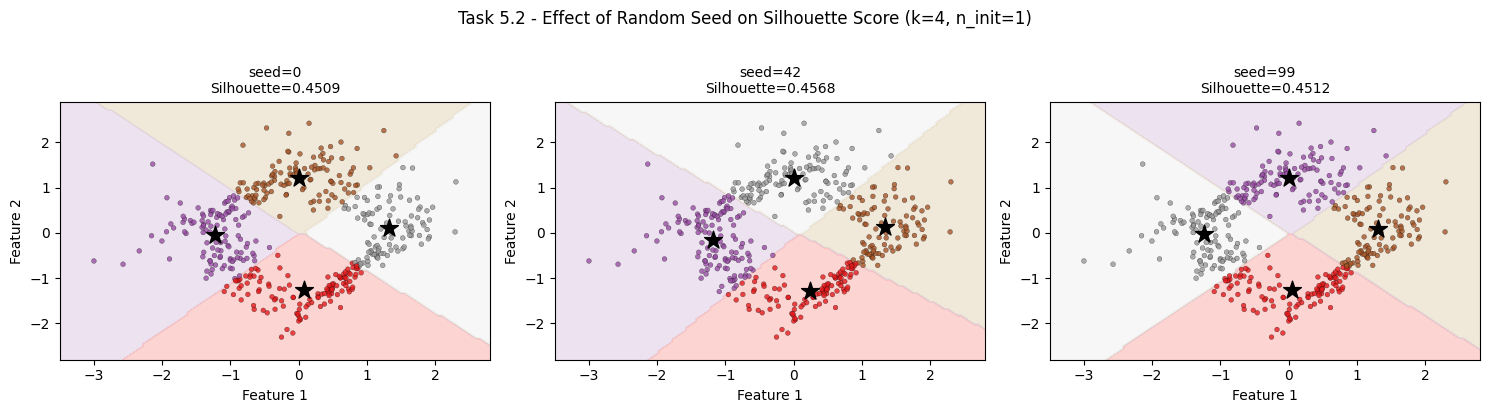


Summary (seed vs silhouette score):
  seed=  0  →  silhouette=0.4509
  seed= 42  →  silhouette=0.4568
  seed= 99  →  silhouette=0.4512


In [42]:
seeds     = [0, 42, 99]  # Using 42 as one of the seeds (matches RANDOM_STATE)
K_FIXED   = N_CLASSES  # Using 4
sil_by_seed = {}

fig, axes = plt.subplots(1, len(seeds), figsize=(15, 4), sharey=False)

for ax, seed in zip(axes, seeds):
    km = KMeans(n_clusters=K_FIXED, n_init=1, random_state=seed)
    km.fit(X)
    sil = silhouette_score(X, km.labels_)
    sil_by_seed[seed] = sil

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    Z = km.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_bg  = plt.get_cmap("Pastel1", K_FIXED)
    cmap_pts = plt.get_cmap("Set1",    K_FIXED)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.55)
    ax.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap=cmap_pts,
               s=12, edgecolors="k", linewidths=0.2, alpha=0.8)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c="black", marker="*", s=180, zorder=5)
    ax.set_title(f"seed={seed}\nSilhouette={sil:.4f}", fontsize=10)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.suptitle(f"Task 5.2 - Effect of Random Seed on Silhouette Score (k={K_FIXED}, n_init=1)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("\nSummary (seed vs silhouette score):")
for seed, s in sil_by_seed.items():
    print(f"  seed={seed:3d}  →  silhouette={s:.4f}")

### Discussion - Task 5.2 (Effect of Random Seed)

KMeans initialises centroids randomly (here via `k-means++` by default). With `n_init=1` only a **single** initialisation is tried, so the final solution depends heavily on where the centroids start.

| Scenario | Effect |
|---|---|
| **Good seed** | Centroids start near the true cluster centres → the algorithm converges to a near-optimal partition → **high silhouette score** |
| **Bad seed** | Centroids start in poor positions (e.g. two centroids inside the same true cluster) → the algorithm converges to a suboptimal local minimum → **lower silhouette score** |

**Practical implication:** This is precisely why `n_init > 1` is the production default - running multiple restarts and keeping the best (lowest inertia) solution makes the result robust to seed choice. When comparing experimental setups, `n_init=1` deliberately exposes this variance so its magnitude is visible.

**Spread across seeds:** If the silhouette scores across seeds are very similar, the dataset is well-separated and most initialisations lead to the same solution. A large spread indicates that the clusters are ambiguous or poorly separated, making initialisation critical.

---
### Overall Summary

| Parameter varied | Primary effect on silhouette |
|---|---|
| **k (number of clusters)** | Structural - too few merges distinct groups; too many fragments them; the peak silhouette typically identifies the natural cluster count |
| **Random seed (initialisation)** | Stochastic - with `n_init=1` different seeds can trap the model in different local optima; the spread reveals how sensitive the solution is to initialisation |